* * *
## Libraries & Modules

In [6]:
from modules.load_data_integrity import load_and_validate_dataset
from modules.GemNet import *
from modules.results import *

***
## **Load *Train* and *Validation* Datasets**

In [4]:
train_dataset_path = '../data/is2res_train_val_test_lmdbs/data/is2re/100k/train/data.lmdb'
val_dataset_path = '../data/is2res_train_val_test_lmdbs/data/is2re/all/val_id/data.lmdb'

***
## **GemNet-OC - Train (T32 & V8)**
### 

In [ ]:
train = load_and_validate_dataset(train_dataset_path, 32000)
validation = load_and_validate_dataset(val_dataset_path, 8000)

Phase 1: Loading & Fixing Tensors (In-Memory): 100%|██████████| 32000/32000 [01:16<00:00, 418.47it/s] 


Successfully loaded 32000 validated samples into RAM.


Phase 1: Loading & Fixing Tensors (In-Memory): 100%|██████████| 8000/8000 [00:05<00:00, 1407.22it/s]

Successfully loaded 8000 validated samples into RAM.


In [26]:
g_model_32k, g_train_maes_32k, g_val_maes_32k, g_val_loader_32k, g_device_32k, g_preds_32k, g_targets_32k = configure_and_run_gemnet_training(
    train_data=train, 
    val_data=validation, 
    epochs=20, 
    batch_size=32, 
    lr=0.0005
)

Using device: cpu
Starting GemNet-OC training for 20 epochs...
Epoch 001/20 | Train MAE: 8.6771 eV | Val MAE: 1.3837 eV
Epoch 002/20 | Train MAE: 1.2042 eV | Val MAE: 1.0882 eV
Epoch 003/20 | Train MAE: 1.0769 eV | Val MAE: 1.0398 eV
Epoch 004/20 | Train MAE: 1.0183 eV | Val MAE: 0.9868 eV
Epoch 005/20 | Train MAE: 0.9857 eV | Val MAE: 0.9785 eV
Epoch 006/20 | Train MAE: 0.9360 eV | Val MAE: 0.9275 eV
Epoch 007/20 | Train MAE: 0.9013 eV | Val MAE: 0.8964 eV
Epoch 008/20 | Train MAE: 0.8692 eV | Val MAE: 0.8871 eV
Epoch 009/20 | Train MAE: 0.8413 eV | Val MAE: 0.8732 eV
Epoch 010/20 | Train MAE: 0.8228 eV | Val MAE: 0.8640 eV
Epoch 011/20 | Train MAE: 0.9514 eV | Val MAE: 0.9349 eV
Epoch 012/20 | Train MAE: 2.3934 eV | Val MAE: 1.0118 eV
Epoch 013/20 | Train MAE: 0.9383 eV | Val MAE: 0.9522 eV
Epoch 014/20 | Train MAE: 0.9164 eV | Val MAE: 0.9070 eV
Epoch 015/20 | Train MAE: 0.9091 eV | Val MAE: 0.9564 eV
Epoch 016/20 | Train MAE: 0.9141 eV | Val MAE: 0.9381 eV
Epoch 017/20 | Train MAE:

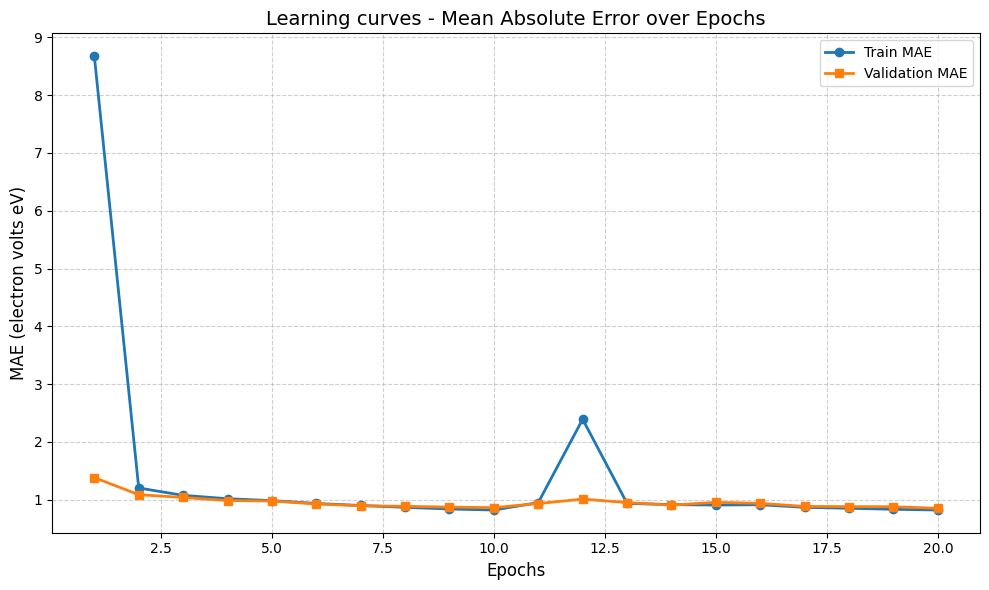

In [31]:
plot_training_curves(g_train_maes_32k, g_val_maes_32k)

In [28]:
summarize_model_metrics(g_preds_32k, g_targets_32k)


--- Model Performance Summary (Validation) ---
Total Samples:      8000
Mean Absolute Error (MAE):  0.8525 eV
Root Mean Sq. Error (RMSE): 1.2291 eV
R-squared (R²):             0.7112
Median Absolute Error:      0.6008 eV
---------------------------------------------


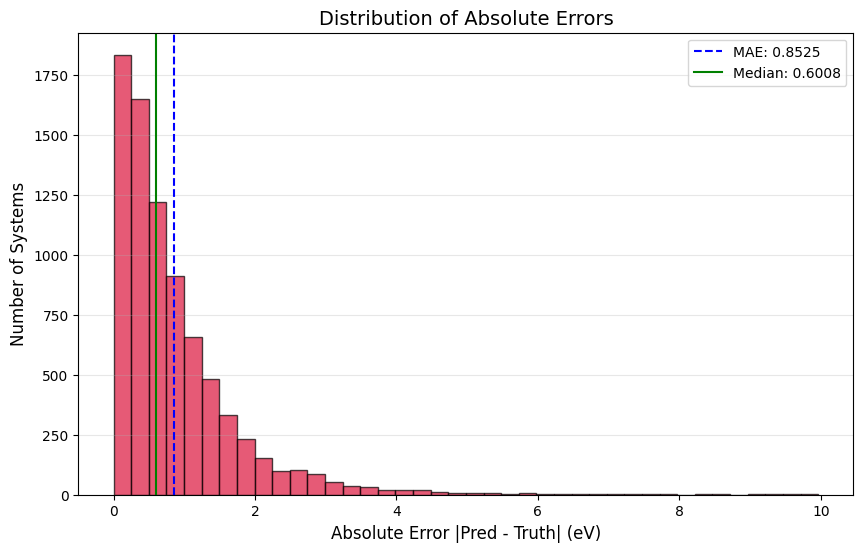

In [29]:
plot_error_distribution(g_preds_32k, g_targets_32k)

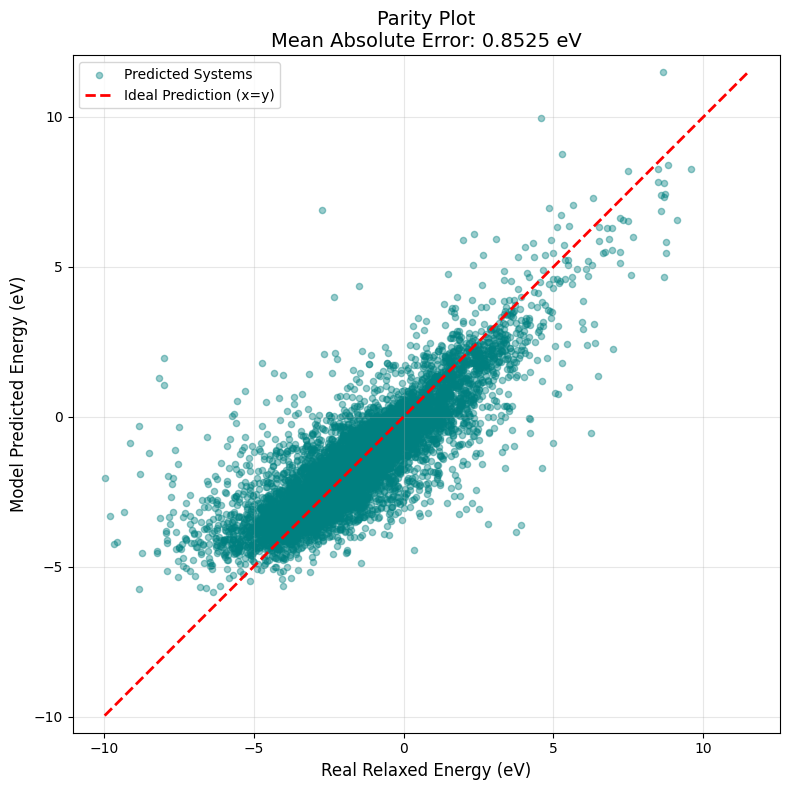

In [30]:
plot_parity_results(g_preds_32k, g_targets_32k)

***
## **GemNet-OC - Train (T100k & V20k)**
### 

In [7]:
train_100 = load_and_validate_dataset(train_dataset_path, 100000)
validation_20 = load_and_validate_dataset(val_dataset_path, 20000)

Phase 1: Loading & Fixing Tensors (In-Memory): 100%|██████████| 100000/100000 [01:01<00:00, 1633.27it/s]


Successfully loaded 100000 validated samples into RAM.


Phase 1: Loading & Fixing Tensors (In-Memory): 100%|██████████| 20000/20000 [00:12<00:00, 1570.72it/s]

Successfully loaded 20000 validated samples into RAM.


In [ ]:
g_model_100k, g_train_maes_100k, g_val_maes_100k, g_val_loader_100k, g_device_100k, g_preds_100k, g_targets_100k = configure_and_run_gemnet_training(
    train_data=train_100, 
    val_data=validation_20, 
    epochs=20, 
    batch_size=32, 
    lr=0.0005
)

Using device: cpu
Starting GemNet-OC training for 20 epochs...
Epoch 001/20 | Train MAE: 3.2896 eV | Val MAE: 1.0880 eV
Epoch 002/20 | Train MAE: 0.9960 eV | Val MAE: 0.9647 eV
Epoch 003/20 | Train MAE: 0.9453 eV | Val MAE: 0.9375 eV


In [ ]:
plot_training_curves(g_train_maes_100k, g_val_maes_100k)

NameError: name 'plot_training_curves' is not defined

In [ ]:
summarize_model_metrics(g_preds_100k, g_targets_100k)

In [ ]:
plot_error_distribution(g_preds_100k, g_targets_100k)

In [ ]:
plot_parity_results(g_preds_100k, g_targets_100k)